A* Algorithm

Shortest Path:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]

Path Length:
8


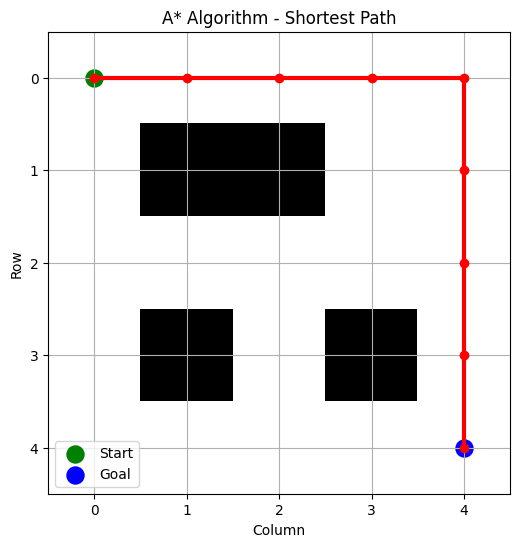

In [1]:
import heapq
import matplotlib.pyplot as plt

# Create the grid
# 0 = free cell
# 1 = obstacle
grid = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)


# Heuristic function
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# A* Algorithm
def astar(graph, start, goal):

    rows = len(graph)
    cols = len(graph[0])

    # Priority queue
    open_list = []

    heapq.heappush(open_list, (0, start))

    # To reconstruct the path
    came_from = {}

    # Cost from start node
    g_score = {
        start: 0
    }

    # Estimated total cost
    f_score = {
        start: heuristic(start, goal)
    }

    # Up, Down, Left, Right
    directions = [
        (-1, 0),   # Up
        (1, 0),    # Down
        (0, -1),   # Left
        (0, 1)     # Right
    ]

    # A* search
    while open_list:

        current_f, current = heapq.heappop(open_list)

        # Goal reached
        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)

            path.reverse()

            return path

        # Get current row and column
        r, c = current

        # Check all directions
        for dr, dc in directions:

            # Calculate new row and column
            nr = r + dr
            nc = c + dc

            # Check boundaries
            if nr < 0 or nr >= rows:
                continue

            if nc < 0 or nc >= cols:
                continue

            # Check obstacle
            if graph[nr][nc] == 1:
                continue

            # New neighboring cell
            neighbor = (nr, nc)

            # Calculate new g score
            tentative_g = g_score[current] + 1

            # If this is a better path
            if neighbor not in g_score or tentative_g < g_score[neighbor]:

                # Store previous node
                came_from[neighbor] = current

                # Update g score
                g_score[neighbor] = tentative_g

                # Calculate f score
                f_score[neighbor] = (
                    tentative_g + heuristic(neighbor, goal)
                )

                # Add neighbor to priority queue
                heapq.heappush(
                    open_list,
                    (f_score[neighbor], neighbor)
                )

    # No path found
    return None


# Run A*
path = astar(grid, start, goal)


# Print result
if path:
    print("Shortest Path:")
    print(path)

    print("\nPath Length:")
    print(len(path) - 1)

else:
    print("No path found")


# -------------------------
# Visualize the grid
# -------------------------

plt.figure(figsize=(6, 6))

# Display grid
plt.imshow(grid, cmap="binary")

# Draw the path
if path:
    path_rows = [p[0] for p in path]
    path_cols = [p[1] for p in path]

    plt.plot(
        path_cols,
        path_rows,
        color="red",
        linewidth=3,
        marker="o"
    )

# Mark start
plt.scatter(
    start[1],
    start[0],
    color="green",
    s=150,
    label="Start"
)

# Mark goal
plt.scatter(
    goal[1],
    goal[0],
    color="blue",
    s=150,
    label="Goal"
)

plt.title("A* Algorithm - Shortest Path")
plt.xlabel("Column")
plt.ylabel("Row")

plt.grid(True)

plt.legend()

plt.show()


Write a code to implement a 8 puzzle problem using A* Algorithm

In [2]:
import heapq

# Goal state representation (0 represents the empty space)
GOAL = (1, 2, 3, 
        4, 5, 6, 
        7, 8, 0)

MOVES = {
    'Up': (-1, 0),
    'Down': (1, 0),
    'Left': (0, -1),
    'Right': (0, 1)
}


def heuristic(state: tuple) -> int:
    """Calculates Manhattan distance heuristic for non-zero tiles."""
    distance = 0
    for i, value in enumerate(state):
        if value == 0:
            continue
        goal_index = GOAL.index(value)
        row1, col1 = divmod(i, 3)
        row2, col2 = divmod(goal_index, 3)
        distance += abs(row1 - row2) + abs(col1 - col2)
    return distance


def get_neighbors(state: tuple) -> list:
    """Generates all valid next states and their corresponding moves."""
    neighbors = []
    zero_index = state.index(0)
    row, col = divmod(zero_index, 3)

    for move, (dr, dc) in MOVES.items():
        new_row, new_col = row + dr, col + dc

        if 0 <= new_row < 3 and 0 <= new_col < 3:
            new_index = new_row * 3 + new_col
            new_state = list(state)
            new_state[zero_index], new_state[new_index] = (
                new_state[new_index],
                new_state[zero_index],
            )
            neighbors.append((tuple(new_state), move))

    return neighbors


def is_solvable(state: tuple) -> bool:
    """Checks if an 8-puzzle state is solvable by counting inversions."""
    numbers = [x for x in state if x != 0]
    inversions = sum(
        1
        for i in range(len(numbers))
        for j in range(i + 1, len(numbers))
        if numbers[i] > numbers[j]
    )
    return inversions % 2 == 0


def reconstruct_path(came_from: dict, current: tuple) -> list:
    """Reconstructs the move list from start to goal."""
    path = []
    while current in came_from:
        current, move = came_from[current]
        path.append(move)
    path.reverse()
    return path


def a_star(start: tuple):
    """Solves the 8-puzzle using A* Search Algorithm."""
    if not is_solvable(start):
        return None

    if start == GOAL:
        return []

    # Priority Queue stores: (f_score, g_score, state)
    pq = [(heuristic(start), 0, start)]
    g_score = {start: 0}
    came_from = {}
    visited = set()

    while pq:
        f, g, current = heapq.heappop(pq)

        if current == GOAL:
            return reconstruct_path(came_from, current)

        if current in visited:
            continue
        visited.add(current)

        for next_state, move in get_neighbors(current):
            tentative_g = g + 1

            if tentative_g < g_score.get(next_state, float('inf')):
                came_from[next_state] = (current, move)
                g_score[next_state] = tentative_g
                f_score = tentative_g + heuristic(next_state)
                heapq.heappush(pq, (f_score, tentative_g, next_state))

    return None


def print_puzzle(state: tuple):
    """Pretty prints the 3x3 puzzle board."""
    for i in range(0, 9, 3):
        print(state[i : i + 3])
    print()


# --- Execution ---
start_state = (1, 2, 3, 
               4, 0, 6, 
               7, 5, 8)

print("Initial State:")
print_puzzle(start_state)

solution = a_star(start_state)

if solution is None:
    print("No solution exists.")
else:
    print("Solution found!")
    print("Number of moves:", len(solution))
    print("Moves:", solution)

    current = start_state
    print("\nSteps:")
    print_puzzle(current)

    for move in solution:
        zero_index = current.index(0)
        row, col = divmod(zero_index, 3)
        dr, dc = MOVES[move]

        new_index = (row + dr) * 3 + (col + dc)
        current_list = list(current)
        current_list[zero_index], current_list[new_index] = (
            current_list[new_index],
            current_list[zero_index],
        )
        current = tuple(current_list)

        print(f"Move: {move}")
        print_puzzle(current)

Initial State:
(1, 2, 3)
(4, 0, 6)
(7, 5, 8)

Solution found!
Number of moves: 2
Moves: ['Down', 'Right']

Steps:
(1, 2, 3)
(4, 0, 6)
(7, 5, 8)

Move: Down
(1, 2, 3)
(4, 5, 6)
(7, 0, 8)

Move: Right
(1, 2, 3)
(4, 5, 6)
(7, 8, 0)

